# Kentucky School Initial Data Review

The goal for this project is to see if there is a correlation between absenteeism and dropout rate. I've decided first to look at the absenteeism data from 2024-2025 and then I will continue on and look at the dropout rate.

Libraries and Parameters

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

seaborn.set_theme(style='whitegrid')


## Chronic Absenteeism Dataset (2024-2025)

In [36]:
absenteeism_df = pd.read_csv("../Dataset/KYRC25_CRDC_Chronic_Absenteeism.csv")

## Initial Dataset Review

In [22]:
absenteeism_df

,School Year,Collected School Year,County Number,County Name,District Number,District Name,School Number,School Name,School Code,State School Id,NCES ID,CO-OP,CO-OP Code,School Type,Demographic,Total,Female,Male
0,20242025,20202021,1,ADAIR,1,Adair County,10,Adair County High School,1010,1001010,210003000000,GRREC,902.0,A1,Total Student Count,783,349.0,434.0
1,20242025,20202021,1,ADAIR,1,Adair County,10,Adair County High School,1010,1001010,210003000000,GRREC,902.0,A1,African American,11,6.0,5.0
2,20242025,20202021,1,ADAIR,1,Adair County,10,Adair County High School,1010,1001010,210003000000,GRREC,902.0,A1,American Indian or Alaska Native,3,1.0,2.0
3,20242025,20202021,1,ADAIR,1,Adair County,10,Adair County High School,1010,1001010,210003000000,GRREC,902.0,A1,Asian,1,NaN,1.0
4,20242025,20202021,1,ADAIR,1,Adair County,10,Adair County High School,1010,1001010,210003000000,GRREC,902.0,A1,Hispanic or Latino,40,14.0,26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7521,20242025,20202021,11,BOYLE,603,Kentucky School for the Deaf,390,Kentucky School for the Deaf,603390,11603390,210010000000,CKEC,901.0,D1,Hispanic or Latino,6,1.0,5.0
7522,20242025,20202021,11,BOYLE,603,Kentucky School for the Deaf,390,Kentucky School for the Deaf,603390,11603390,210010000000,CKEC,901.0,D1,Two or More Races,3,1.0,2.0
7523,20242025,20202021,11,BOYLE,603,Kentucky School for the Deaf,390,Kentucky School for the Deaf,603390,11603390,210010000000,CKEC,901.0,D1,White (non-Hispanic),59,25.0,34.0
7524,20242025,20202021,11,BOYLE,603,Kentucky School for the Deaf,390,Kentucky School for the Deaf,603390,11603390,210010000000,CKEC,901.0,D1,Students with Disabilities (IEP),7,3.0,4.0


## Analyzing the Data

In [23]:
absenteeism_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7526 entries, 0 to 7525
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   School Year            7526 non-null   int64  
 1   Collected School Year  7526 non-null   int64  
 2   County Number          7526 non-null   int64  
 3   County Name            7526 non-null   str    
 4   District Number        7526 non-null   int64  
 5   District Name          7526 non-null   str    
 6   School Number          7526 non-null   int64  
 7   School Name            7526 non-null   str    
 8   School Code            7526 non-null   int64  
 9   State School Id        7526 non-null   int64  
 10  NCES ID                7526 non-null   int64  
 11  CO-OP                  7519 non-null   str    
 12  CO-OP Code             7519 non-null   float64
 13  School Type            7526 non-null   str    
 14  Demographic            7526 non-null   str    
 15  Total          

In [24]:
absenteeism_df.columns = absenteeism_df.columns.str.strip()

In [25]:
absenteeism_df.isnull().sum()

School Year                 0
Collected School Year       0
County Number               0
County Name                 0
District Number             0
District Name               0
School Number               0
School Name                 0
School Code                 0
State School Id             0
NCES ID                     0
CO-OP                       7
CO-OP Code                  7
School Type                 0
Demographic                 0
Total                       0
Female                   1035
Male                      728
dtype: int64

In [26]:
absenteeism_df.isna().sum()

School Year                 0
Collected School Year       0
County Number               0
County Name                 0
District Number             0
District Name               0
School Number               0
School Name                 0
School Code                 0
State School Id             0
NCES ID                     0
CO-OP                       7
CO-OP Code                  7
School Type                 0
Demographic                 0
Total                       0
Female                   1035
Male                      728
dtype: int64

Research why Female/Male have missing values

In [27]:
absenteeism_df.duplicated().sum()

np.int64(0)

In [28]:
absenteeism_df.groupby('School Name')['Total'].agg(["mean", "min", "max"])

,mean,min,max
School Name,,,
A B Chandler Elementary School,29.166667,1,87
A M Yealey Elementary School,13.000000,2,49
Abraham Lincoln Elementary School,13.000000,1,32
Ackerly,1.833333,1,5
Adair County Elementary School,145.875000,1,574
...,...,...,...
Yellow Creek School Center,166.555556,1,748
Young Elementary,51.375000,1,180
Zachary Taylor Elementary,60.750000,1,206


In [29]:
absenteeism_df.groupby('District Name')['Total'].sum().sort_values(ascending=False)

District Name
Jefferson County                 139230
Fayette County                    31814
Boone County                      16219
Warren County                     12949
Oldham County                     12164
                                  ...  
Kentucky School for the Blind        65
Robertson County                     58
Augusta Independent                  52
East Bernstadt Independent           52
Anchorage Independent                20
Name: Total, Length: 172, dtype: int64

## Data Cleanup

In [30]:
school_df = absenteeism_df[absenteeism_df["Demographic"] != "Total Student Count"]
school_df.sort_values(by="Total",ascending=False).head(10)

,School Year,Collected School Year,County Number,County Name,District Number,District Name,School Number,School Name,School Code,State School Id,NCES ID,CO-OP,CO-OP Code,School Type,Demographic,Total,Female,Male
500,20242025,20202021,8,BOONE,35,Boone County,71,Larry A. Ryle High School,35071,8035071,210051000000,NKCES,905.0,A1,White (non-Hispanic),1388,659.0,729.0
6013,20242025,20202021,93,OLDHAM,465,Oldham County,60,Oldham County High School,465060,93465060,210453000000,OVEC,906.0,A1,White (non-Hispanic),1288,609.0,679.0
3138,20242025,20202021,51,HENDERSON,251,Henderson County,60,Henderson County High School,251060,51251060,210271000000,WKEC,908.0,A1,White (non-Hispanic),1215,557.0,658.0
3856,20242025,20202021,56,JEFFERSON,275,Jefferson County,105,Ballard High,275105,56275105,210299000000,GREC,909.0,A1,White (non-Hispanic),1062,560.0,502.0
2725,20242025,20202021,43,GRAYSON,211,Grayson County,85,Grayson County High School,211085,43211085,210230000000,GRREC,902.0,A1,White (non-Hispanic),1057,463.0,594.0
4154,20242025,20202021,56,JEFFERSON,275,Jefferson County,200,duPont Manual High,275200,56275200,210299000000,GREC,909.0,A1,White (non-Hispanic),1041,593.0,448.0
409,20242025,20202021,8,BOONE,35,Boone County,15,Randall K. Cooper High School,35015,8035015,210051000000,NKCES,905.0,A1,White (non-Hispanic),976,450.0,526.0
4098,20242025,20202021,56,JEFFERSON,275,Jefferson County,179,Central High Magnet Career Academy,275179,56275179,210299000000,GREC,909.0,A1,African American,931,660.0,271.0
5126,20242025,20202021,71,LOGAN,351,Logan County,140,Logan County High School,351140,71351140,210354000000,GRREC,902.0,A1,White (non-Hispanic),917,459.0,458.0
3670,20242025,20202021,56,JEFFERSON,275,Jefferson County,75,Pleasure Ridge Park High,275075,56275075,210299000000,GREC,909.0,A1,White (non-Hispanic),893,432.0,461.0


Removing Total Student Count to avoid skewing the dataset

In [31]:
gender_school_df = school_df[['Female', 'Male']].sum()
gender_school_df

Female    117080.0
Male      134118.0
dtype: float64

In [32]:
school_df.isna().sum()

sorted_school_df = school_df.sort_values(by="Total", ascending=False)

In [33]:
county_large_df = sorted_school_df.groupby("County Name")["Total"].sum().sort_values(ascending=False).head(10) 
county_large_df

County Name
JEFFERSON    74165
FAYETTE      17277
BOONE         8632
WARREN        7742
DAVIESS       7045
OLDHAM        6175
KENTON        6011
HENDERSON     4407
BELL          3678
PULASKI       3338
Name: Total, dtype: int64

## Visual Analysis and Discovery

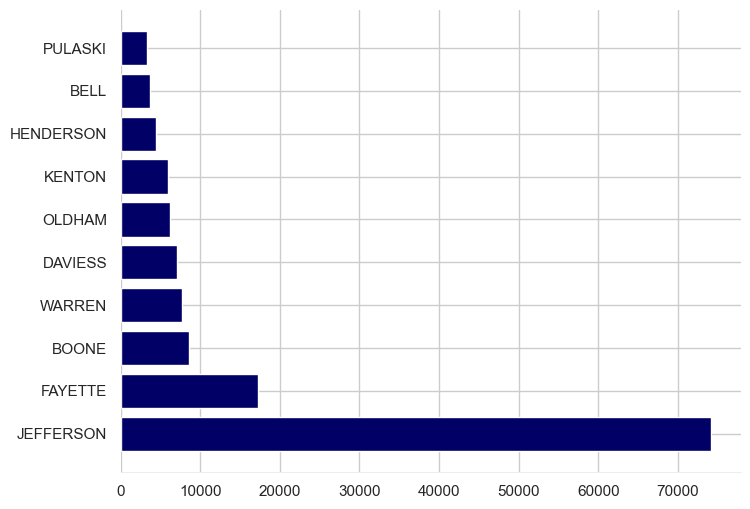

In [40]:
plt.figure(figsize=(8,6))

plt.barh(county_large_df.index, county_large_df.values, color="#000066")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.show()

Jefferson County has the highest absenteeism total in this view. I'll need to bring in enrollment rate to get %s and see how it compares this way. This may help to shed some light on the large delta.

Bring in older datasets, is the absentee count flat, or trending up/down?

# Visualizations and Analysis

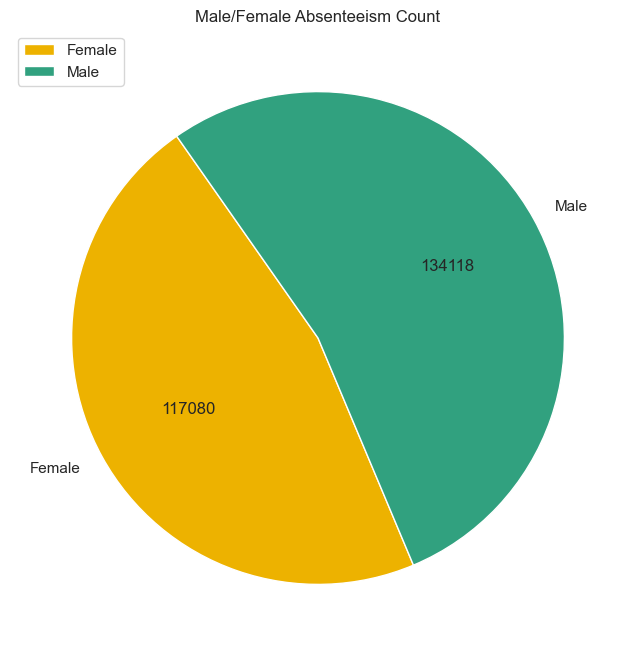

In [41]:
plt.figure(figsize=(8,8))

plt.pie(
    gender_school_df,
    labels=gender_school_df.index,
    startangle=125,
    colors=[ "#EDB200", "#31a17f"],
    autopct=lambda g: '{:.0f}'.format(g * gender_school_df.sum()/100)
)

plt.title("Male/Female Absenteeism Count")

plt.legend(
    labels = gender_school_df.index,
    loc="upper left",
    # title = "Platform"
)

plt.show()


For 2024/2025, male absentee counts appear to be slightly higher than female counts

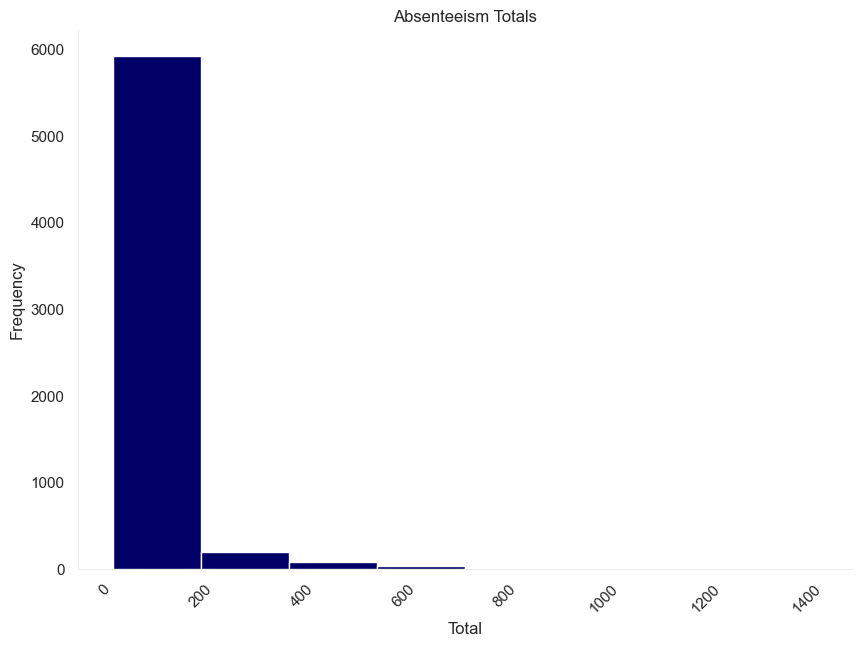

In [45]:
plt.figure(figsize=(10,7))

school_df["Total"].hist(bins=8, grid=False, color="#000066")

plt.title("Absenteeism Totals")
plt.xlabel("Total")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha="right")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

plt.show()

Most counties are within the lower absenteeism ranges with a few exceptions in the higher end.

## Key Findings for Absenteeism Dataset (2024/2025)
=> Jefferson County has the highest number of absenteeism total in this dataset.

=> Most counties have fairly low number of absentieeism totals.

=> Male Absenteeism counts are slightly higher Female Absenteeism counts.

=> Enrollment data will need to be brought in for further review

I'll need to look at historical data and enrollment data for a more holistic view of what is going on with this data, before I to jump to conclusions... 

## What I've learned!

It's important to keep my Markdown language area organized and clean. It can be easy for me to get lost in the lack of organization with these notebooks.

Just because counts may be higher for one group over another doesn't necessarily mean this is an accurate depiction of what the data is telling me. Some counties will have higher enrollment data than others. Jefferson County is a great example of this. It's a heavily populated county and this can make it appear that it has higher % of absenteeism than other counties.